# IA para Cibersegurança- Aula 2
## Fundamentos de ML e IA + classificador

**Dupla:** `Eduardo Henrique`  ·  `Gabriel de Medeiros`

Nesta aula a gente amarra os conceitos de ML (já vistos na aula anterior de conceitos básicos e análise de dados) e constrói **um classificador completo**, do treino ao uso. Vamos treinar esse modelo no **Teachable Machine** e carregá-lo aqui no notebook.

> Guarde bem o modelo e o conjunto de teste desta aula: **este classificador que você vai poder atacar na aula 10** (ataques de evasão).

Referência de apoio: Géron, *Hands-On Machine Learning*, caps. 1 (panorama) e 2 (projeto de ponta a ponta).

## Parte A - Conceitos

**Onde ML se situa dentro de IA**
- **IA** — qualquer sistema que exibe comportamento "inteligente".
  - **ML** — subárea da IA: o sistema *aprende padrões a partir de dados*, em vez de seguir regras escritas à mão.
    - **Deep learning** — ML com redes neurais profundas (é o que o Teachable Machine usa por baixo).
    - **LLMs** — modelos de linguagem de grande porte; um tipo específico de deep learning para texto. Retomados na Etapa 2 (segurança de LLMs).

**Tipos de aprendizado**
- **Supervisionado** — dados rotulados; o modelo aprende a mapear entrada → rótulo. *Ex. em segurança:* classificar e-mail como phishing ou legítimo. É o que faremos hoje.
- **Não supervisionado** — dados sem rótulo; o modelo encontra estrutura sozinho. *Ex.:* detecção de anomalias em fraude (aula 6).

**Treino / validação / teste** — separamos os dados em três para não nos enganarmos:
- **treino** ajusta o modelo; **validação** guia as escolhas (quando parar, qual configuração); **teste** mede o desempenho **em dados nunca vistos**. Medir no próprio treino infla o resultado.

**Sobreajuste (overfitting)** — o modelo decora o treino em vez de generalizar: vai muito bem no treino e mal no teste. O conjunto de teste independente é o que revela isso.

**Anatomia de um pipeline de ML** — a espinha de tudo que faremos no semestre:
1. dados → 2. representação/features → 3. treino → 4. avaliação → 5. uso (inferência).

Hoje cada etapa aparece de forma concreta: o Teachable Machine cuida de (1)–(3), e nós fazemos (4) e (5) aqui no notebook.

## Parte B — Classificador com o Teachable Machine

**Por que Teachable Machine?** Treina um classificador de imagem **sem código**, o que nivela a turma, e exporta um modelo Keras real (baseado em MobileNet). Esse mesmo modelo será o **alvo dos ataques de evasão na aula 10** — por isso construímos ele agora.

Link: https://teachablemachine.withgoogle.com/

### Passo 1 — Treinar o modelo (no navegador)
1. Abra o Teachable Machine → **Get Started** → **Image Project** → **Standard image model**.
2. Crie **2 ou 3 classes** simples e visualmente distintas (ex.: dois objetos diferentes, ou "com máscara" / "sem máscara").
3. Em cada classe, adicione **~40 a 80 imagens** (webcam ou upload). **Varie fundo, ângulo e iluminação** — isso é o que faz o modelo *generalizar* em vez de *decorar* (overfitting).
4. Clique em **Train Model** e teste na pré-visualização.


### Passo 2 — Exportar (e separar um teste honesto)
1. **Export Model** → aba **Tensorflow** → formato **Keras** → **Download my model**. Você recebe `converted_keras.zip` com `keras_model.h5` e `labels.txt`.
2. **Antes de sair**, separe de **10 a 15 imagens por classe que você NÃO usou no treino** — é o nosso conjunto de teste independente. Fotografe/junte à parte.

### Passo 3 — Organizar no Drive
Vamos colocar o modelo em `models/` e as imagens de teste em `data/test/<nome-da-classe>/`, usando **exatamente os mesmos nomes de classe** do Teachable Machine.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJETO = Path('/content/drive/MyDrive/ia-ciberseguranca')
(PROJETO / 'models').mkdir(parents=True, exist_ok=True)
(PROJETO / 'data' / 'test').mkdir(parents=True, exist_ok=True)

print('Coloque converted_keras.zip em:', PROJETO / 'models')
print('Coloque as imagens de teste em: ', PROJETO / 'data' / 'test' / '<classe>')

Mounted at /content/drive
Coloque converted_keras.zip em: /content/drive/MyDrive/ia-ciberseguranca/models
Coloque as imagens de teste em:  /content/drive/MyDrive/ia-ciberseguranca/data/test/<classe>


In [ ]:
# Descompacta o modelo exportado do Teachable Machine
import zipfile

ZIP = PROJETO / 'models' / 'converted_keras.zip'
DEST = PROJETO / 'models'
with zipfile.ZipFile(ZIP) as z:
    z.extractall(DEST)

H5     = DEST / 'keras_model.h5'
LABELS = DEST / 'labels.txt'
print('Modelo :', H5.exists(), H5)
print('Labels :', LABELS.exists(), LABELS)

Modelo : True /content/drive/MyDrive/ia-ciberseguranca/models/keras_model.h5
Labels : True /content/drive/MyDrive/ia-ciberseguranca/models/labels.txt


### Carregar o modelo
O `.h5` do Teachable Machine é exportado com uma versão antiga do Keras e costuma **quebrar no TF atual do Colab** (erro clássico no `DepthwiseConv2D` por causa do argumento `groups`, e Keras 3 vs Keras 2). O bloco abaixo resolve os dois pontos: liga o modo de compatibilidade (Keras 2 via `tf_keras`) e aplica um patch na camada. Ele **precisa rodar antes de qualquer uso do TensorFlow** nesta sessão.

In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # carrega modelos Keras 2 (Teachable Machine) sob TF novo
%pip install -q tf_keras

import tensorflow as tf
from tensorflow.keras.layers import DepthwiseConv2D
print('TensorFlow', tf.__version__)

# Patch: versões antigas salvam 'groups' no DepthwiseConv2D; o Keras novo não entende
class PatchedDepthwiseConv2D(DepthwiseConv2D):
    def __init__(self, *args, **kwargs):
        kwargs.pop('groups', None)
        super().__init__(*args, **kwargs)

model = tf.keras.models.load_model(
    H5, compile=False,
    custom_objects={'DepthwiseConv2D': PatchedDepthwiseConv2D})

class_names = [l.strip().split(' ', 1)[-1]
               for l in open(LABELS, encoding='utf-8') if l.strip()]
print('Classes:', class_names)
model.summary()

TensorFlow 2.20.0
Classes: ['Bicicleta', 'Moto']
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 1280)              410208    
                                                                 
 sequential_3 (Sequential)   (None, 2)                 128300    
                                                                 
Total params: 538508 (2.05 MB)
Trainable params: 524428 (2.00 MB)
Non-trainable params: 14080 (55.00 KB)
_________________________________________________________________


### Pré-processamento e inferência
O Teachable Machine usa entrada **224×224 RGB** normalizada para o intervalo **[-1, 1]** (`pixel/127.5 - 1`). Precisamos replicar isso exatamente, senão a predição sai errada.

In [ ]:
import numpy as np
from PIL import Image, ImageOps

try:
    RESAMPLE = Image.Resampling.LANCZOS
except AttributeError:
    RESAMPLE = Image.LANCZOS

def carregar_imagem(caminho, tamanho=224):
    img = Image.open(caminho).convert('RGB')
    img = ImageOps.fit(img, (tamanho, tamanho), RESAMPLE)
    arr = np.asarray(img).astype(np.float32)
    return (arr / 127.5) - 1.0            # normalização do Teachable Machine

def prever(caminho):
    x = carregar_imagem(caminho)[None, ...]
    probs = model.predict(x, verbose=0)[0]
    i = int(np.argmax(probs))
    return class_names[i], float(probs[i]), probs

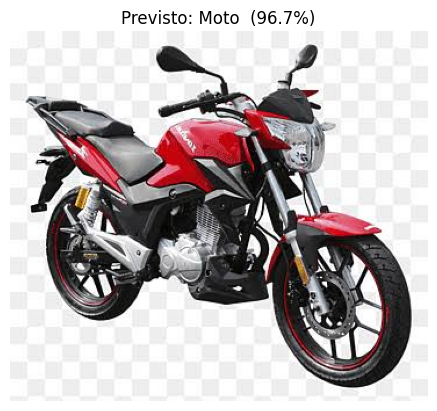

In [ ]:
# Teste rápido com UMA imagem (aponte para um arquivo do seu data/test)
import matplotlib.pyplot as plt

exemplos = list((PROJETO / 'data' / 'test').rglob('*'))
exemplos = [p for p in exemplos if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
assert exemplos, 'Coloque imagens em data/test/<classe>/ antes de rodar.'

alvo = exemplos[2]
classe, conf, _ = prever(alvo)
plt.imshow(Image.open(alvo)); plt.axis('off')
plt.title(f'Previsto: {classe}  ({conf:.1%})')
plt.show()

### Treino / validação / teste — na prática
O Teachable Machine já separou **treino e validação** internamente enquanto treinava. Agora fazemos o que falta: medir o modelo no **nosso conjunto de teste independente**, com imagens que ele nunca viu. Se a acurácia aqui for bem menor que a mostrada no Teachable Machine, isso é **overfitting**.

Imagens de teste : 16
Acurácia no teste: 100.0%

              precision    recall  f1-score   support

   Bicicleta       1.00      1.00      1.00        10
        Moto       1.00      1.00      1.00         6

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



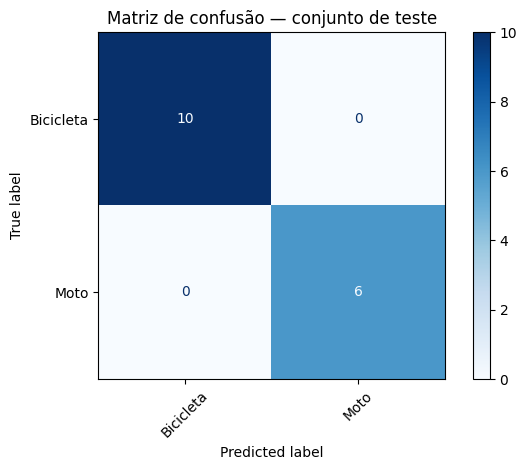

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

TEST_DIR = PROJETO / 'data' / 'test'
y_true, y_pred = [], []

for classe_dir in sorted(d for d in TEST_DIR.iterdir() if d.is_dir()):
    for img in classe_dir.glob('*'):
        if img.suffix.lower() not in {'.jpg', '.jpeg', '.png'}:
            continue
        nome, _, _ = prever(img)
        y_true.append(classe_dir.name)
        y_pred.append(nome)

print(f'Imagens de teste : {len(y_true)}')
print(f'Acurácia no teste: {accuracy_score(y_true, y_pred):.1%}\n')
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=class_names)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title('Matriz de confusão — conjunto de teste')
plt.tight_layout(); plt.show()

### Discussão (respondam no notebook)
- A acurácia no **nosso teste** ficou próxima da que o Teachable Machine mostrou? Se caiu, **por quê**? (pista: variedade das imagens de treino)
- Onde cada etapa do **pipeline** apareceu nesta aula? (dados → representação MobileNet → treino no TM → avaliação aqui → uso)
- Que classe o modelo mais confunde? O que isso sugere sobre as *features* que ele aprendeu?

1.
A acurácia atingiu 100%, igual a do teachable machine. foi muito boa a variedade de imagens que colocamos, qualidade das imagens. se tivesse uma falha ou queda , seria pelo overfitting.


2.
Os dados aconteceram na coleta das imagens das motos e bicicletas que foram adicionadas tanto no drive quanto no teachable machine para treinar a ia.

Representação na hora de tratar da imagem em si, pela função de "carregar imagem " e redimensionando elas.

Treino no TM: foi o treinamento da ia no teachable machine, a interface web.

Avaliação: Execução da célula accuracy_score. que mostra o relatorio de classificação e matriz.

Uso: Chamada da função "prever". para classificar as imagens que são ineditas e responder com a probabilidade.


3.
Foi escolhido inclusive estas duas categorias, pois detem de muitas similaridades, guidão, duas rodas, estrutura parecida. Erros de previsão indicariam que a rede neural priorizou essas geometrias gerais de veículos de duas rodas em vez de extrair detalhes distintivos, como a presença de motor e os pedais.




In [ ]:
# Guardar o modelo do projeto para reuso na aula 10 (ataques de evasão)
import shutil
shutil.copy(H5, PROJETO / 'models' / 'modelo_aula2.h5')
(PROJETO / 'models' / 'labels_aula2.txt').write_text('\n'.join(class_names) + '\n')
print('Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.')

Modelo salvo em models/modelo_aula2.h5 — não apague, será atacado na aula 10.


## Entregável da aula
- [] Modelo treinado no Teachable Machine e carregado no notebook
- [] Inferência funcionando
- [] Avaliação no conjunto de teste independente (acurácia + matriz de confusão)
- [] Respostas da discussão
- [] `modelo_aula2.h5` e imagens de teste salvos no projeto

**Próxima aula:** dados e features em segurança — escolha da base do projeto e dicionário de features.
**Aula 10:** este mesmo modelo podera ser alvo de ataques de evasão. Não apague o `.h5` nem o conjunto de teste.